## Other manifold learning methods: MDS, Isomap, Spectral Embedding, LTSA

In [14]:
import pandas as pd

df_pos = pd.read_csv("../../data/inputs/descriptors_positive_staphylococcus.csv")
df_neg_01 = pd.read_csv("../../data/inputs/descriptors_negative_01_dataset.csv")
df_neg_02 = pd.read_csv("../../data/inputs/descriptors_negative_02_dataset.csv")
df_neg_03 = pd.read_csv("../../data/inputs/descriptors_negative_03_dataset.csv")

# show shapes
print(f"Positive dataset shape: {df_pos.shape}")
print(f"Negative 01 dataset shape: {df_neg_01.shape}")
print(f"Negative 02 dataset shape: {df_neg_02.shape}")
print(f"Negative 03 dataset shape: {df_neg_03.shape}")

# merge into one dataframe
df = pd.concat([df_pos, df_neg_01, df_neg_02, df_neg_03])

Positive dataset shape: (442, 104)
Negative 01 dataset shape: (442, 104)
Negative 02 dataset shape: (442, 104)
Negative 03 dataset shape: (442, 104)


In [15]:
# drop columns "SEQUENCE" and "ACTIVITY"
df = df.drop(columns=["SEQUENCE", "ACTIVITY"])

In [16]:
# normalizing the data using MinMaxScaler
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(df)
df_feat = pd.DataFrame(scaled_features, columns=df.columns)

# variance treshold - remove features with zero variance
from sklearn.feature_selection import VarianceThreshold
selector = VarianceThreshold()
selector.fit(df_feat)
df_feat = df_feat[df_feat.columns[selector.get_support(indices=True)]]
print("-----Variance treshold-----")
print(f"Features dropped: {df.columns[~selector.get_support()]}")
print(f"New shape: {df_feat.shape}\n")


# trash randomly one of the features with correlation > 0.85
import numpy as np
corr_matrix = df_feat.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(np.bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.85)]
df_feat = df_feat.drop(columns=to_drop)
print("-----Correlation filter-----")
print(f"Features dropped: {to_drop}")
print(f"New shape: {df_feat.shape}\n")


# trash all features with "BLOSUM" in the name
to_drop = [col for col in df_feat.columns if "BLOSUM" in col]
df_feat = df_feat.drop(columns=to_drop)
print("-----Filter by name-----")
print(f"Features dropped: {to_drop}")
print(f"New shape: {df_feat.shape}\n")

-----Variance treshold-----
Features dropped: Index([], dtype='object')
New shape: (1768, 102)

-----Correlation filter-----
Features dropped: ['F2', 'F3', 'KF1', 'KF2', 'KF4', 'MSWHIM1', 'E1', 'E2', 'E5', 'PD1', 'PD2', 'PRIN1', 'PRIN2', 'ProtFP1', 'ProtFP2', 'SV2', 'ST1', 'ST6', 'SVGER1', 'SVGER7', 'SVGER10', 'T1', 'T4', 'T5', 'VHSE1', 'VHSE2', 'VHSE3', 'VHSE5', 'VHSE8', 'VSTPV1', 'VSTPV2', 'VSTPV3', 'Z1', 'Z2', 'Z4']
New shape: (1768, 67)

-----Filter by name-----
Features dropped: ['BLOSUM1', 'BLOSUM2', 'BLOSUM3', 'BLOSUM4', 'BLOSUM5', 'BLOSUM6', 'BLOSUM7', 'BLOSUM8', 'BLOSUM9', 'BLOSUM10']
New shape: (1768, 57)


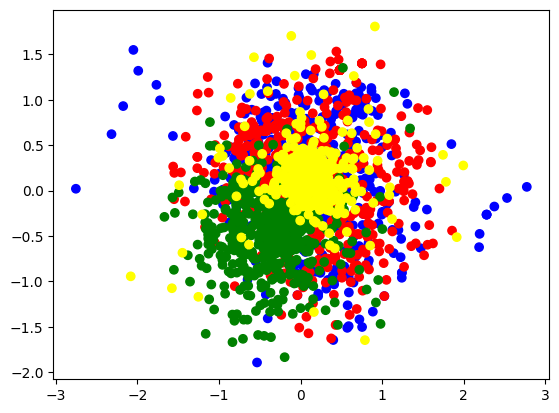

In [17]:
# MDS
from sklearn.manifold import MDS
import matplotlib.pyplot as plt

mds = MDS(n_components=2)
X_mds = mds.fit_transform(df_feat)
plt.scatter(X_mds[:, 0], X_mds[:, 1], c=df_pos.shape[0]*["blue"] + df_neg_01.shape[0]*["red"] + df_neg_02.shape[0]*["green"] + df_neg_03.shape[0]*["yellow"])
plt.title("MDS")
plt.savefig("MDS.png")
plt.show()

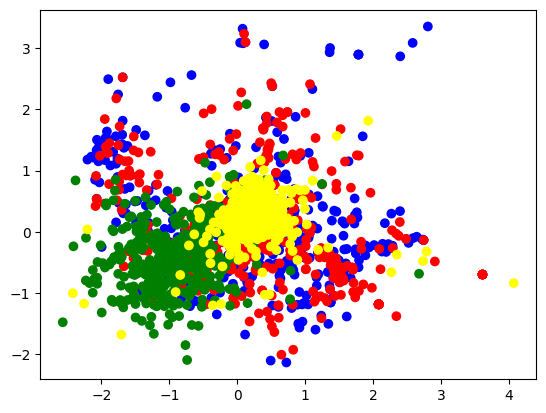

In [18]:
# Isomap
from sklearn.manifold import Isomap

isomap = Isomap(n_components=2)
X_iso = isomap.fit_transform(df_feat)
plt.scatter(X_iso[:, 0], X_iso[:, 1], c=df_pos.shape[0]*["blue"] + df_neg_01.shape[0]*["red"] + df_neg_02.shape[0]*["green"] + df_neg_03.shape[0]*["yellow"])
plt.title("Isomap")
plt.savefig("Isomap.png")
plt.show()


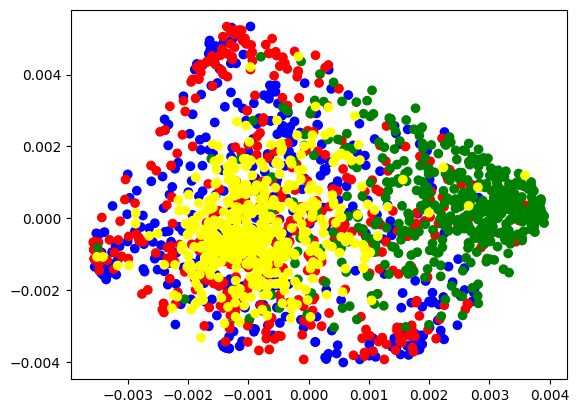

In [19]:
# spectral embedding
from sklearn.manifold import SpectralEmbedding

spectral = SpectralEmbedding(n_components=2)
X_spectral = spectral.fit_transform(df_feat)
plt.scatter(X_spectral[:, 0], X_spectral[:, 1], c=df_pos.shape[0]*["blue"] + df_neg_01.shape[0]*["red"] + df_neg_02.shape[0]*["green"] + df_neg_03.shape[0]*["yellow"])
plt.title("Spectral Embedding")
plt.savefig("Spectral Embedding.png")
plt.show()

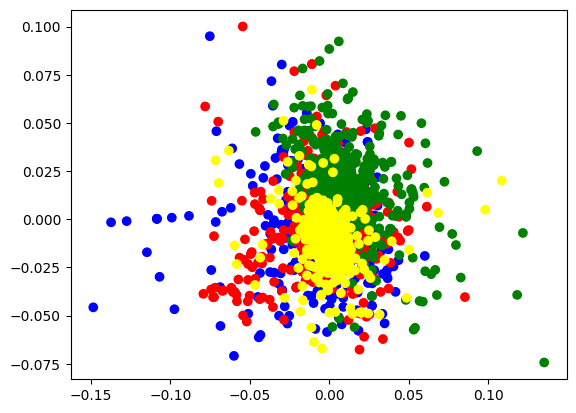

In [33]:
# LTSA, more neibors
from sklearn.manifold import LocallyLinearEmbedding

ltsa = LocallyLinearEmbedding(n_components=2, n_neighbors=30)
X_ltsa = ltsa.fit_transform(df_feat)
plt.scatter(X_ltsa[:, 0], X_ltsa[:, 1], c=df_pos.shape[0]*["blue"] + df_neg_01.shape[0]*["red"] + df_neg_02.shape[0]*["green"] + df_neg_03.shape[0]*["yellow"])
plt.title("Locally Linear Embedding")
plt.savefig("Locally Linear Embedding.png")
plt.show()